In [2]:
import pickle as pkl 
import pandas as pd

In [3]:
df=pd.read_csv("newdataset/test.csv")

df.head()

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents
0,517754,highway,2,0.34,45,night,clear,True,True,afternoon,True,True,1
1,517755,urban,3,0.04,45,dim,foggy,True,False,afternoon,True,False,0
2,517756,urban,2,0.59,35,dim,clear,True,False,afternoon,True,True,1
3,517757,rural,4,0.95,35,daylight,rainy,False,False,afternoon,False,False,2
4,517758,highway,2,0.86,35,daylight,clear,True,False,evening,False,True,3


In [4]:
model=pkl.load(open("model/model.pkl","rb"))

test=pd.read_csv("newdataset/test.csv")


In [5]:
cat_cols = df.select_dtypes(include='object').columns
print(cat_cols)

Index(['road_type', 'lighting', 'weather', 'time_of_day'], dtype='str')


C:\Users\kisha\AppData\Local\Temp\ipykernel_13148\133485905.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


In [6]:
from sklearn.preprocessing import LabelEncoder

cat_cols = test.select_dtypes(include='object').columns

le_dict = {}

for col in cat_cols:
    le = LabelEncoder()
    test[col] = le.fit_transform(test[col])
    le_dict[col] = le


C:\Users\kisha\AppData\Local\Temp\ipykernel_13148\180371496.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = test.select_dtypes(include='object').columns


In [7]:
predictions=model.predict(test)


df['pred_accident_risk'] = predictions

df.head()

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,pred_accident_risk
0,517754,highway,2,0.34,45,night,clear,True,True,afternoon,True,True,1,0.292896
1,517755,urban,3,0.04,45,dim,foggy,True,False,afternoon,True,False,0,0.135575
2,517756,urban,2,0.59,35,dim,clear,True,False,afternoon,True,True,1,0.188760
3,517757,rural,4,0.95,35,daylight,rainy,False,False,afternoon,False,False,2,0.324498
4,517758,highway,2,0.86,35,daylight,clear,True,False,evening,False,True,3,0.391659


In [8]:
import os 
os.makedirs("predicted_data",exist_ok=True)
df.to_csv("predicted_data/prediction_output", index=False)

In [9]:
def convert_risk(value):
    if value < 0.33:
        return "Low"
    elif value < 0.66:
        return "Medium"
    else:
        return "High"

df["Risk_Level"] = df["pred_accident_risk"].apply(convert_risk)

In [10]:
df[['pred_accident_risk', 'Risk_Level']].head(30)

,pred_accident_risk,Risk_Level
0,0.292896,Low
1,0.135575,Low
2,0.188760,Low
3,0.324498,Low
4,0.391659,Medium
5,0.462775,Medium
6,0.265276,Low
7,0.198361,Low
8,0.360922,Medium
9,0.345447,Medium


C:\Users\kisha\AppData\Local\Temp\ipykernel_13148\3004029499.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


Text(0.5, 1.0, 'Distribution of accident risk level')

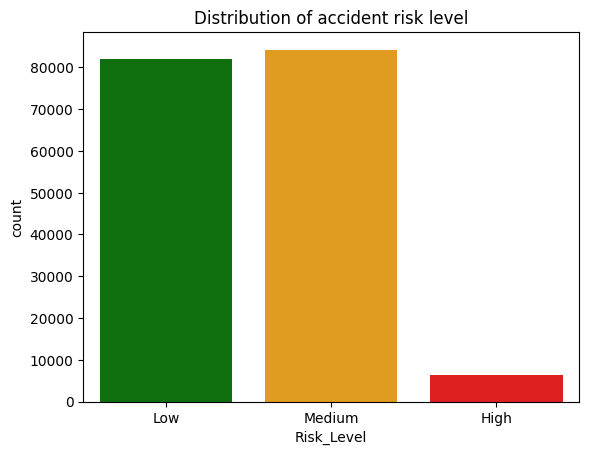

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt 

sns.countplot(
    x="Risk_Level",
    data=df,
    palette={"Low": "green", "Medium": "orange", "High": "red"}
)

plt.title("Distribution of accident risk level")